In [1]:
from datetime import datetime

# U.S. Industry ETFs
us_industry_etfs = {
    "XLF": "Financials",                # Financial Select Sector SPDR Fund
    "XLK": "Technology",                # Technology Select Sector SPDR Fund
    "XLE": "Energy",                    # Energy Select Sector SPDR Fund
    "XLI": "Industrials",               # Industrial Select Sector SPDR Fund
    "XLU": "Utilities",                 # Utilities Select Sector SPDR Fund
    "XLP": "Consumer Staples",          # Consumer Staples Select Sector SPDR Fund
    "XLY": "Consumer Discretionary",    # Consumer Discretionary Select Sector SPDR Fund
    "XLV": "Health Care",               # Health Care Select Sector SPDR Fund
    "XLB": "Materials",                 # Materials Select Sector SPDR Fund
    "XLRE": "Real Estate"               # Real Estate Select Sector SPDR Fund
}

trading_days_in_year = 252
# Define the start and end dates for fetching the data
start_date = '1990-01-01'
end_date = datetime.today().strftime("%Y-%m-%d")

In [2]:
!pip install pandas yfinance matplotlib seaborn

In [3]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

returns_df = pd.DataFrame()

# Fetch daily returns for each ticker
for ticker, asset_class in us_industry_etfs.items():
    try:
        # Fetch historical data for the ticker
        data = yf.download(ticker)
        
        # Check if the data is empty
        if data.empty:
            print(f"No data found for ticker: {ticker}")
            continue
        
        # Calculate daily returns
        data['Daily Return'] = data['Adj Close'].pct_change()
        
        # Add the daily returns to the returns DataFrame
        data = data[['Daily Return']].rename(columns={'Daily Return': asset_class})
        if returns_df.empty:
            returns_df = data
        else:
            returns_df = returns_df.join(data, how='outer')
    except Exception as e:
        print(f"Failed for ticker: {ticker}")
        print(e)
        
# Drop the first row with NaN values
returns_df = returns_df.iloc[1:]
returns_df.to_csv("../data/historical-class-returns.csv")
# Display the first few rows of the returns DataFrame

# VERY IMPORTANT, OTHERWISE MANY COMPUTATIONS WOULD RETURN NONE, FROM 
# PORT OPT, to RISK CONT!
returns_df.fillna(0, inplace=True)
returns_df.head()

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


,Financials,Technology,Energy,Industrials,Utilities,Consumer Staples,Consumer Discretionary,Health Care,Materials,Real Estate
Date,,,,,,,,,,
1998-12-23,0.014746,0.023891,0.020819,0.017450,-0.004191,0.024174,0.004295,0.022471,0.010503,0.0
1998-12-24,0.006603,-0.003809,-0.005263,0.013193,0.018411,-0.001727,0.018325,0.006105,0.023014,0.0
1998-12-28,-0.013123,0.002868,-0.005291,0.005208,-0.005165,-0.005767,-0.008998,-0.014562,-0.008708,0.0
1998-12-29,0.010639,0.002860,0.009974,0.014248,0.016615,0.022042,0.021792,0.022167,0.018301,0.0
1998-12-30,-0.003947,-0.003803,-0.015141,-0.004470,-0.008172,-0.006243,-0.008294,-0.008434,-0.002876,0.0


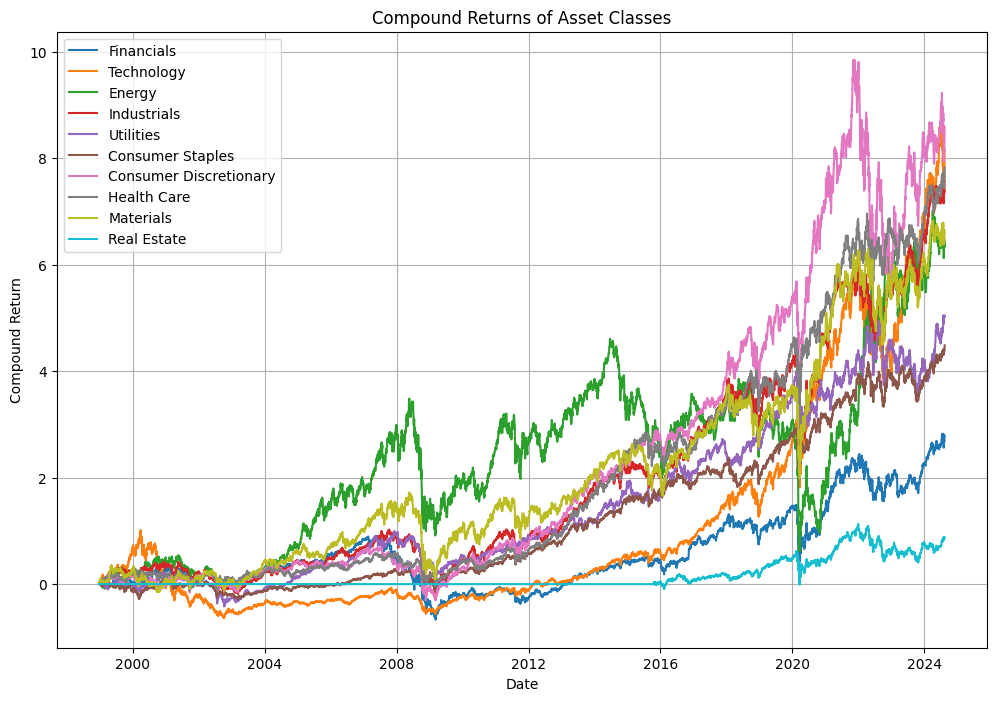

In [4]:
# Calculate compound returns
compound_returns = (1 + returns_df).cumprod() - 1

# Plot the compound returns
plt.figure(figsize=(12, 8))
for column in compound_returns.columns:
    plt.plot(compound_returns.index, compound_returns[column], label=column)

plt.title('Compound Returns of Asset Classes')
plt.ylabel('Compound Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

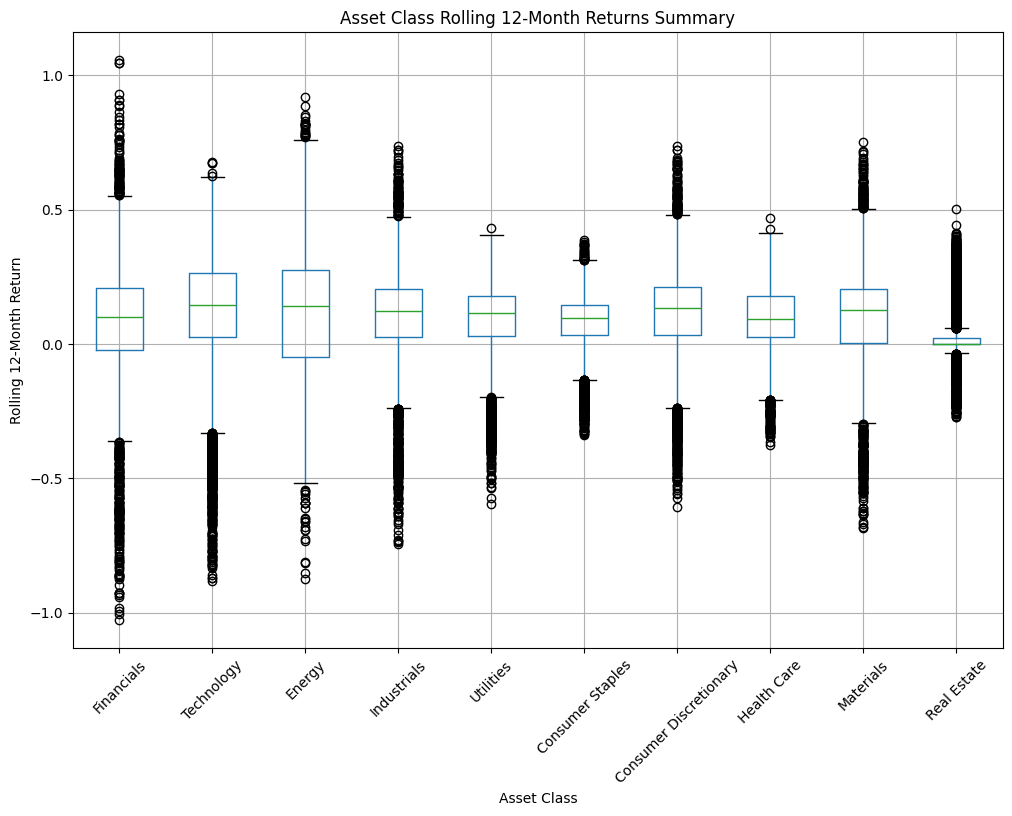

In [5]:
# Calculate 12-month rolling returns
rolling_returns = returns_df.rolling(window=trading_days_in_year).sum()  # 252 trading days in a year

# Plot the box and whisker chart for rolling 12-month returns
plt.figure(figsize=(12, 8))
rolling_returns.boxplot()
plt.title('Asset Class Rolling 12-Month Returns Summary')
plt.ylabel('Rolling 12-Month Return')
plt.xlabel('Asset Class')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

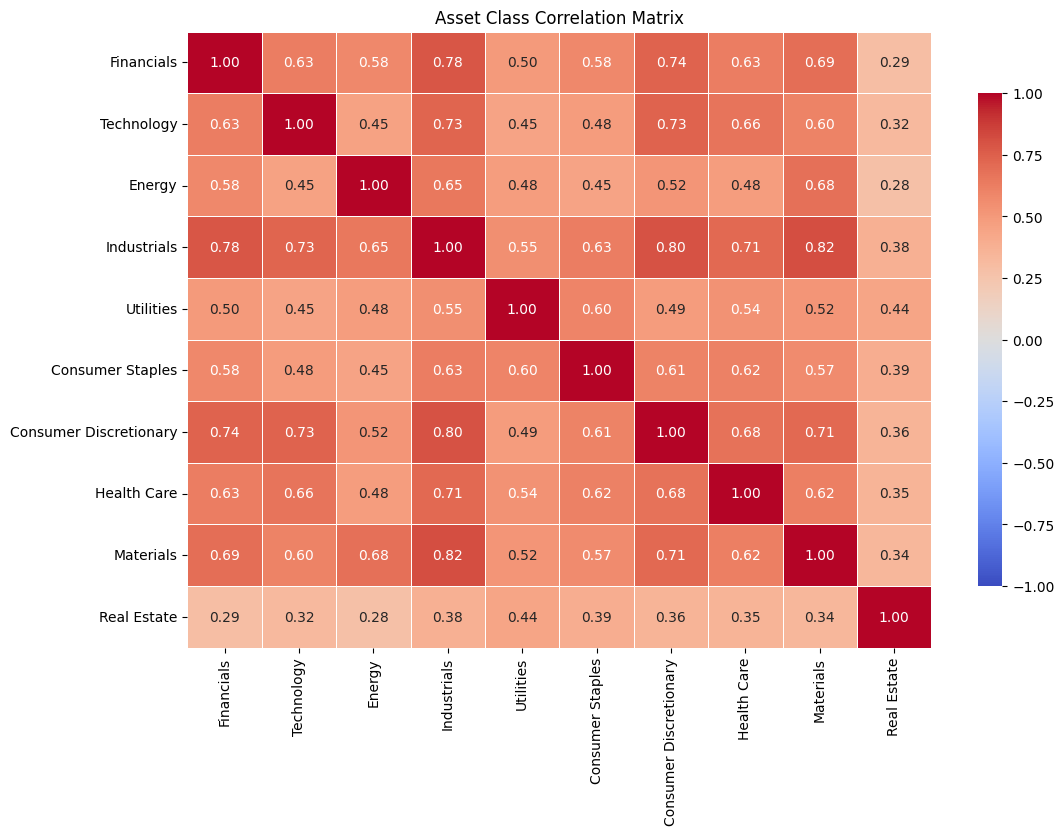

In [6]:
import seaborn as sns

# Calculate the correlation matrix of the daily returns
correlation_matrix = returns_df.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            linewidths=0.5, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Asset Class Correlation Matrix')
plt.show()


Now let's compare performance of an equal contribution portfolio against a mean-variance optimized one, rebalancing on a quarterly basis

/home/alan/Quantropy/src/portfolio_optimization.py:191: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  stored_weights_filled = stored_weights_shifted.ffill().fillna(0)


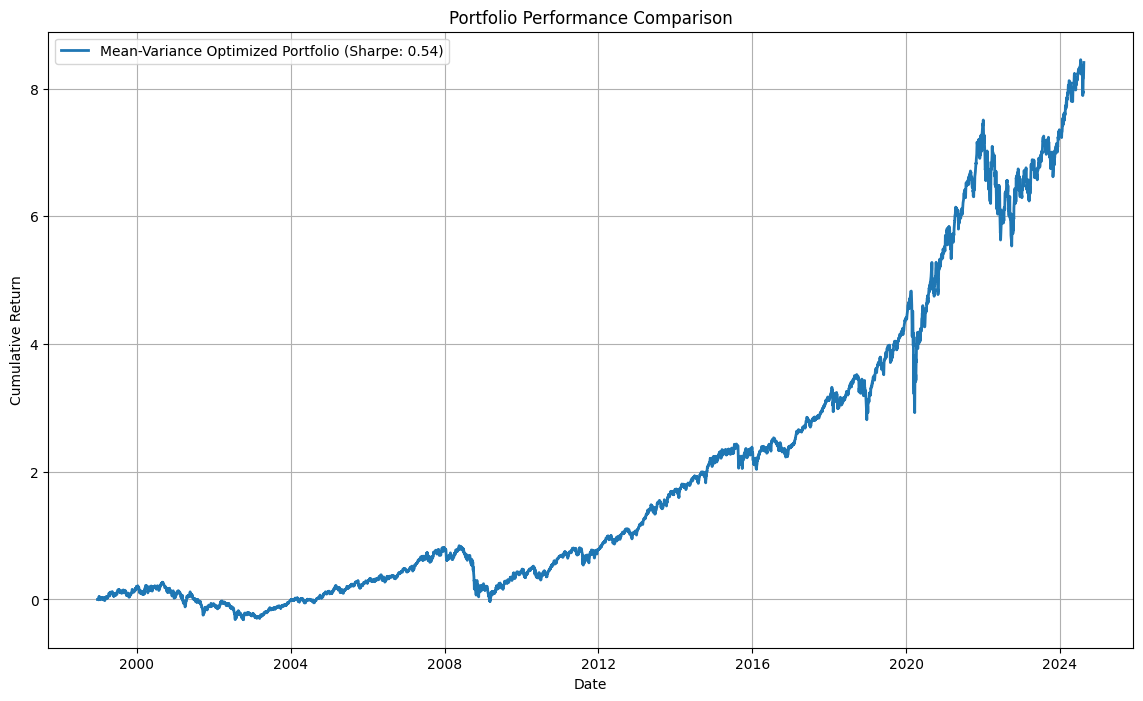

In [43]:
from portfolio_optimization import *

portfolio_returns, weights = portfolio_allocation(returns_df, frequency='daily', method='maxSharpe',
                                                               max_exposure=0.3)

post_processing = portfolio_performance(portfolio_returns=portfolio_returns, frequency="daily")

# Plot the performance
plot_portfolio_performance(portfolio_cum=post_processing["cumulative_returns"], sharpe=post_processing["sharpe_ratio"])

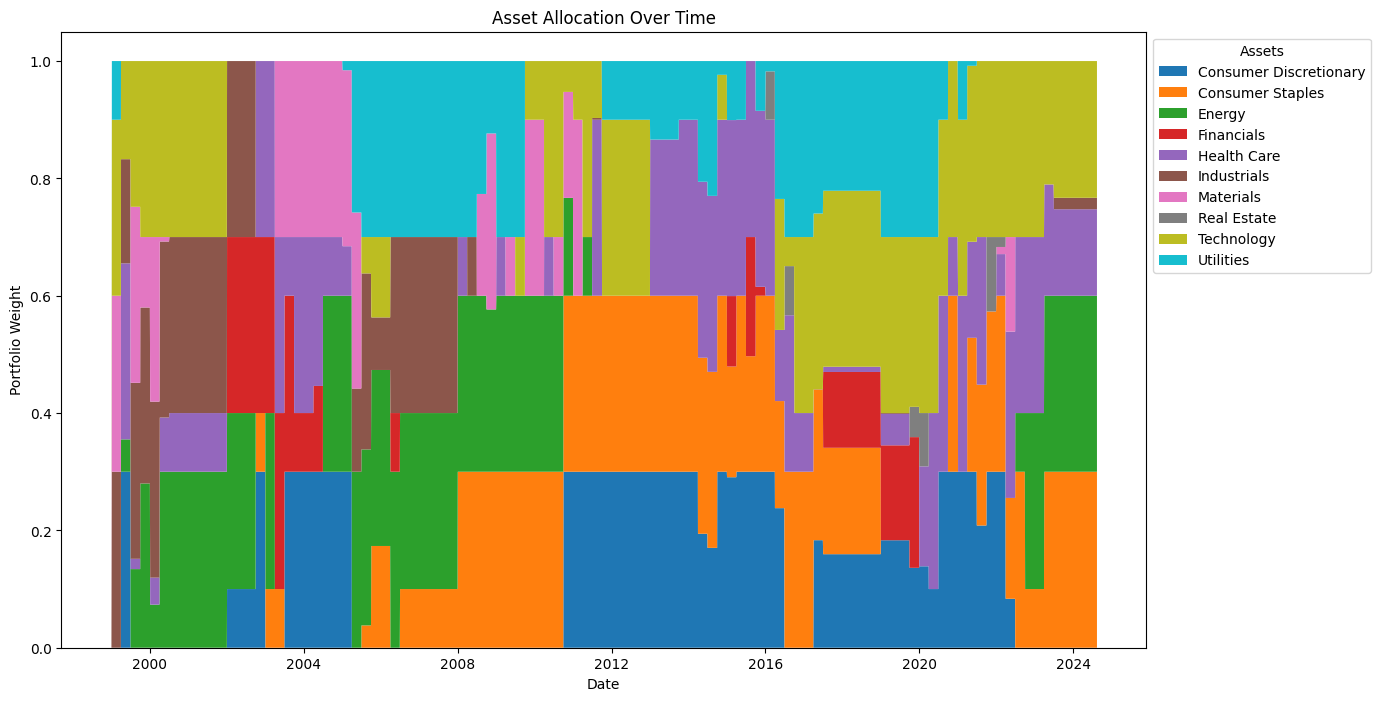

In [44]:
plot_portfolio_allocation_history(weights_df=weights)

/tmp/ipykernel_6767/4218793229.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mu = np.arange(-max(R),max(R)*5,max(R)/100);


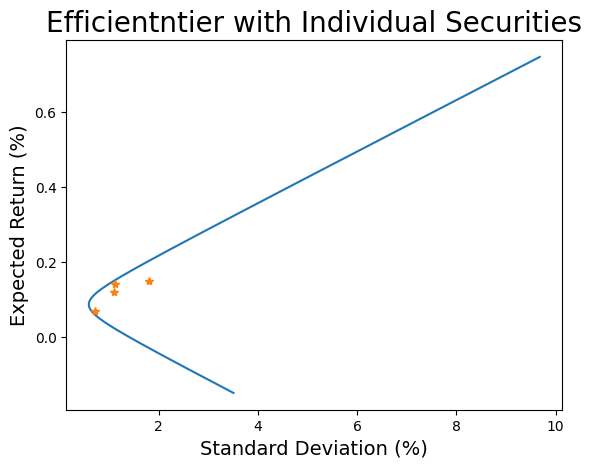

AttributeError: Line2D.set() got an unexpected keyword argument 'fontsize'

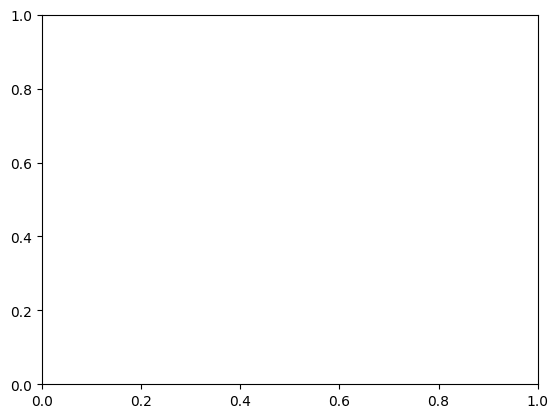

In [50]:
from __future__ import division
from matplotlib import pyplot as plt
from numpy.linalg import inv,pinv

""" USING THE MATRIX NOTATION DEFINED IN
APPENDIX OF "A CRITIQUE OF THE ASSET PRICING THEORY'S TESTS" ROLL (1977) 
"""

# USER INPUT
V = np.matrix('123 37.5 70 30; 37.5 122 72 13.5; 70 72 321 -32; 30 13.5 -32 52')/100  # covariance
R = np.matrix('14; 12; 15; 7')/100 # return
rf = 3/100 # risk free

# define the 
I = np.ones((len(R),1))
SD = np.sqrt(np.diag(V))

# Variable for Efficient frontier (SEE (A.9) ROLL 1977 page 160)
C = I.T*pinv(V)*I 
B = R.T*pinv(V)*I
A = R.T*pinv(V)*R
D = A*C-B**2

########################################################
#EFFICIENT FRONTIER
########################################################
# Efficient Frontier Range for Return
mu = np.arange(-max(R),max(R)*5,max(R)/100);
 
# Plot Efficient Frontier
minvar = (A-2*B*mu+(C*mu**2))/D;
minstd = np.sqrt(minvar)[0];
minstd = np.squeeze(np.asarray(minstd))
plt.plot(minstd,mu,SD,R,'*')
plt.title('Efficientntier with Individual Securities',fontsize=20)
plt.ylabel('Expected Return (%)', fontsize=14)
plt.xlabel('Standard Deviation (%)', fontsize=14)
plt.show()


########################################################
#MVP
########################################################
# Mean and Variance of Global Minimum Variance Portfolio
mu_g = B/C
var_g = 1/C
std_g = np.sqrt(var_g)

# Minimum Variance Portfolio Weights
w_g = (pinv(V)*I)/C

# Plot Efficient Frontier
minvar = (A-2*B*mu+(C*mu**2))/D;
minstd = np.sqrt(minvar)[0];
minstd = np.squeeze(np.asarray(minstd))
plt.plot(minstd,mu,SD,R,'*',std_g,mu_g,fontsize=20)
plt.ylabel('Expected Return (%)', fontsize=14)
plt.xlabel('Standard Deviation (%)', fontsize=14)
plt.show()


########################################################
#TANGENT PORTFOLIO
########################################################
# Expected Return of Tangency Portfolio
mu_tan = (B*rf-A)/(C*rf-B);
 
# Variance and Standard Deviation of Tangency Portfolio
vartan = (A-2*rf*B + (rf**2*C))/((B-C*rf)**2);
stdtan = np.sqrt(vartan);
 
# Weights for Tangency Portfolio
w_tan = (pinv(V)*(R - rf*I))/(B-C*rf)

# Tangency Line
m_tan = mu[mu >= rf];
minvar_rf = (m_tan-rf)**2/(A-2*rf*B+C*rf**2);
minstd_rf = np.sqrt(minvar_rf);
minstd_rf = np.squeeze(np.asarray(minstd_rf))

# Plot with tangency portfolio
plt.plot(minstd,mu,SD,R,'*',minstd_rf,m_tan,'r',std_g,mu_g,'bo',stdtan,mu_tan,goplt.title('Efficientntier with Individual Securities',fontsize=18))
plt.ylabel('Expected Return (%)', fontsize=12)
plt.xlabel('Standard Deviation (%)', fontsize=12)
plt.text(0.5,rf,'rf') # ,fontsize=12plt.tplt.text(0.5+std_g,mu_g,'Globalimum Variance Portfolio',fontsize=12);
plt.text(0.5+stdtan,mu_tan,'Tangencytfolio',fontsize=12);
plt.show()